# 智能数据分析师（Agent Data Analyst）

## 项目简介

本项目基于 **Hello-Agents 1.x** 框架构建了一个「智能数据分析师」Agent。用户只需用自然语言提出数据分析需求，Agent 即可自主完成 **数据加载 → 数据质量诊断 → 统计分析 → 数据清洗 → 可视化图表生成 → 业务洞察总结** 的完整分析流程，让不会编程的业务人员也能一键获得专业的数据分析报告。

**核心特性：**
- 🗣️ 自然语言交互：零代码完成数据分析
- 🔧 Function Calling：Agent 自主规划并调用 4 个专业数据分析工具
- 📊 自动可视化：根据分析意图自动选择合适图表类型
- 💡 业务洞察：不止给数字，更给出可执行的业务建议

## 作者信息
- 姓名：孟凡超
- GitHub：BeiXiao-929
- 日期：2026-9-3

## 项目结构

```
BeiXiao-929-AI-Powered-Data-Analyst-Agent/
├── main.ipynb              # 本文件：项目主程序
├── README.md               # 项目说明文档
├── requirements.txt        # 依赖清单
├── data/
│   └── sample_sales.csv    # 示例数据（100条记录，含缺失值/重复行）
└── outputs/                # 图表与分析结果输出目录
```

## 环境说明

本项目依赖 **hello-agents ≥ 1.0.0**（新版 API：`Tool` / `ToolRegistry` / `ToolResponse`）。若按旧版教程使用 `BaseTool`/`agent.add_tool()` 会报 `ImportError`。


## 第2部分：环境配置

### 2.1 安装依赖（首次运行执行一次）

```bash
pip install -r requirements.txt
# 或：pip install "hello-agents>=1.0.0" pandas matplotlib python-dotenv
```

### 2.2 配置密钥（重要）

新版 `HelloAgentsLLM` 从 **`LLM_API_KEY`**（不是 `ZHIPU_API_KEY`）读取密钥。
本项目使用 `api.env` 文件，请在项目根目录的 `api.env` 中确认/补齐三个变量：

```bash
LLM_MODEL_ID=glm-4-flash
LLM_API_KEY=你的智谱API密钥        # ← 注意键名，旧模板常误写为 ZHIPU_API_KEY
LLM_BASE_URL=https://open.bigmodel.cn/api/paas/v4
```


In [8]:
# 若未安装依赖，可取消下面一行的注释后执行（已安装则跳过）
# %pip install -q -r requirements.txt

# 导入必要的库
from hello_agents import SimpleAgent, HelloAgentsLLM
from hello_agents.tools import Tool, ToolParameter, ToolResponse, ToolRegistry, ToolErrorCode
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from dotenv import load_dotenv

# 解决 matplotlib 中文乱码
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

# 加载环境变量（兼容 .env 与 api.env 两种命名）
load_dotenv()
load_dotenv("api.env")

DATA_PATH = "data/sample_sales.csv"
print("环境配置完成 ✅")
print(f"当前模型: {os.getenv('LLM_MODEL_ID')} | 密钥已配置: {bool(os.getenv('LLM_API_KEY'))}")

环境配置完成 ✅
当前模型: glm-4-flash | 密钥已配置: True


## 第3部分：工具定义

适配 hello-agents 1.x 新版 API 定义 4 个数据分析工具（继承 `Tool`，返回 `ToolResponse`，用 `get_parameters()` 声明结构化参数）：

| 工具 | 名称 | 参数 | 功能 |
|------|------|------|------|
| `CSVLoaderTool` | `csv_loader` | file_path | 加载数据集，返回规模、字段、样例、缺失值、重复行诊断 |
| `DataStatsTool` | `data_stats` | file_path, column | 数值列描述性统计 + 类别列分布统计 |
| `DataCleanTool` | `data_cleaner` | file_path | 缺失值填充、去重，保存清洗后数据并返回报告 |
| `DataVizTool` | `data_visualizer` | file_path, chart_type, x_column, y_column | 柱状/折线/饼图/直方图/散点图，保存到 outputs/ |


In [9]:
class CSVLoaderTool(Tool):
    """数据加载工具：读取CSV并返回数据全貌与质量诊断"""

    def __init__(self):
        super().__init__(
            name="csv_loader",
            description=(
                "加载CSV数据集并返回数据概览，包括：数据规模、字段及类型、前5行样例、"
                "各列缺失值数量、重复行数量。数据分析的第一步应调用本工具。"
            ),
        )

    def run(self, parameters: dict) -> ToolResponse:
        path = str(parameters.get("file_path", "")).strip().strip("'\"")
        if not os.path.exists(path):
            return ToolResponse.error(code=ToolErrorCode.INVALID_PARAM,
                                      message=f"文件 {path} 不存在，请检查路径")
        try:
            df = pd.read_csv(path)
        except Exception as e:
            return ToolResponse.error(code=ToolErrorCode.INVALID_FORMAT,
                                      message=f"读取文件失败: {e}")
        missing = df.isnull().sum()
        missing = missing[missing > 0]
        info = {
            "文件路径": path,
            "数据规模": f"{df.shape[0]} 行 x {df.shape[1]} 列",
            "字段及类型": {col: str(dtype) for col, dtype in df.dtypes.items()},
            "前5行样例": df.head().to_dict(orient="records"),
            "缺失值统计": {k: int(v) for k, v in missing.items()} if len(missing) else "无缺失值",
            "重复行数量": int(df.duplicated().sum()),
        }
        text = json.dumps(info, ensure_ascii=False, indent=2, default=str)
        return ToolResponse.success(text=text, data=info)

    def get_parameters(self):
        return [
            ToolParameter(name="file_path", type="string",
                          description="CSV文件路径，例如 data/sample_sales.csv", required=True),
        ]


class DataStatsTool(Tool):
    """统计分析工具：数值列描述性统计 + 类别列分布"""

    def __init__(self):
        super().__init__(
            name="data_stats",
            description=(
                "对数据集做统计分析：自动输出所有数值列的 count/mean/std/min/25%/50%/75%/max，"
                "以及低基数类别列的取值分布(Top5)。如需只看某一列，可传入 column 参数。"
            ),
        )

    def run(self, parameters: dict) -> ToolResponse:
        path = str(parameters.get("file_path", "")).strip().strip("'\"")
        if not os.path.exists(path):
            return ToolResponse.error(code=ToolErrorCode.INVALID_PARAM,
                                      message=f"文件 {path} 不存在")
        df = pd.read_csv(path)
        result = {"文件": path}

        column = parameters.get("column")
        if column and column in df.columns:
            series = df[column]
            if pd.api.types.is_numeric_dtype(series):
                result["列统计"] = series.describe().round(2).to_dict()
            else:
                vc = series.value_counts(dropna=False).head(10)
                result["取值分布"] = {str(k): int(v) for k, v in vc.items()}
            return ToolResponse.success(
                text=json.dumps(result, ensure_ascii=False, indent=2, default=str), data=result)

        numeric_cols = df.select_dtypes(include="number").columns.tolist()
        if numeric_cols:
            result["数值列统计"] = df[numeric_cols].describe().round(2).to_dict()
        cat_cols = df.select_dtypes(exclude="number").columns.tolist()
        cat_dist = {}
        for col in cat_cols:
            vc = df[col].value_counts().head(5)
            if len(vc) <= 10:
                cat_dist[col] = {str(k): int(v) for k, v in vc.items()}
        if cat_dist:
            result["类别列分布(Top5)"] = cat_dist
        return ToolResponse.success(
            text=json.dumps(result, ensure_ascii=False, indent=2, default=str), data=result)

    def get_parameters(self):
        return [
            ToolParameter(name="file_path", type="string",
                          description="CSV文件路径，例如 data/sample_sales.csv", required=True),
            ToolParameter(name="column", type="string",
                          description="要重点分析的列名（可选，省略则分析全表）",
                          required=False, default=""),
        ]


class DataCleanTool(Tool):
    """数据清洗工具：缺失值填充 + 去重，保存清洗结果并返回报告"""

    def __init__(self):
        super().__init__(
            name="data_cleaner",
            description=(
                "清洗数据集：数值列缺失值用中位数填充、类别列缺失值用众数填充、删除重复行。"
                "清洗后的数据保存到 outputs/ 目录，返回清洗报告。"
            ),
        )

    def run(self, parameters: dict) -> ToolResponse:
        path = str(parameters.get("file_path", "")).strip().strip("'\"")
        if not os.path.exists(path):
            return ToolResponse.error(code=ToolErrorCode.INVALID_PARAM,
                                      message=f"文件 {path} 不存在")
        df = pd.read_csv(path)
        report = {"原始规模": f"{df.shape[0]} 行 x {df.shape[1]} 列"}

        # 1. 缺失值处理
        missing_before = df.isnull().sum()
        missing_before = missing_before[missing_before > 0]
        fill_detail = {}
        for col in missing_before.index:
            if pd.api.types.is_numeric_dtype(df[col]):
                fill_value = df[col].median()
                strategy = "中位数"
            else:
                fill_value = df[col].mode().iloc[0] if not df[col].mode().empty else "未知"
                strategy = "众数"
            df[col] = df[col].fillna(fill_value)
            fill_detail[col] = f"{int(missing_before[col])} 个缺失值已用{strategy}({fill_value})填充"
        report["缺失值处理"] = fill_detail if fill_detail else "无缺失值"

        # 2. 去重
        dup_count = int(df.duplicated().sum())
        if dup_count:
            df = df.drop_duplicates().reset_index(drop=True)
        report["重复行处理"] = f"删除 {dup_count} 条重复行"

        # 3. 保存
        os.makedirs("outputs", exist_ok=True)
        cleaned_path = f"outputs/cleaned_{os.path.basename(path)}"
        df.to_csv(cleaned_path, index=False, encoding="utf-8-sig")
        report["清洗后规模"] = f"{df.shape[0]} 行 x {df.shape[1]} 列"
        report["清洗后文件"] = cleaned_path
        return ToolResponse.success(
            text=json.dumps(report, ensure_ascii=False, indent=2, default=str), data=report)

    def get_parameters(self):
        return [
            ToolParameter(name="file_path", type="string",
                          description="待清洗的CSV文件路径", required=True),
        ]


class DataVizTool(Tool):
    """可视化工具：根据分析意图生成图表并保存到 outputs/"""

    def __init__(self):
        super().__init__(
            name="data_visualizer",
            description=(
                "生成数据可视化图表。chart_type 支持：bar(柱状图-对比各类别)、"
                "line(折线图-展示趋势)、pie(饼图-展示占比)、hist(直方图-展示分布)、"
                "scatter(散点图-看两列关系)。"
                "bar/pie 省略 y_column 时按计数统计；hist 只需 x_column 传数值列；"
                "scatter/line 需要 x_column 与 y_column。"
            ),
        )

    def run(self, parameters: dict) -> ToolResponse:
        path = str(parameters.get("file_path", "")).strip().strip("'\"")
        chart_type = str(parameters.get("chart_type", "")).lower()
        x_col = parameters.get("x_column") or ""
        y_col = parameters.get("y_column") or ""
        if not os.path.exists(path):
            return ToolResponse.error(code=ToolErrorCode.INVALID_PARAM, message=f"文件 {path} 不存在")
        df = pd.read_csv(path)

        # 数值化容错：空字符串会被读成 object，转数值并丢弃无效行
        if y_col and y_col in df.columns:
            df[y_col] = pd.to_numeric(df[y_col], errors="coerce")
        df = df.dropna(subset=[c for c in [x_col, y_col] if c and c in df.columns])

        plt.figure(figsize=(10, 6))
        try:
            if chart_type == "bar":
                if y_col:
                    data = df.groupby(x_col)[y_col].sum().sort_values(ascending=False)
                    plt.bar(data.index.astype(str), data.values, color="#3498db")
                    plt.ylabel(y_col)
                else:
                    data = df[x_col].value_counts()
                    plt.bar(data.index.astype(str), data.values, color="#3498db")
                    plt.ylabel("数量")
                plt.title(f"{x_col} 分组统计（柱状图）")
            elif chart_type == "line":
                df = df.sort_values(x_col) if x_col in df.columns else df
                plt.plot(df[x_col].astype(str), df[y_col], marker="o", color="#e74c3c")
                plt.title(f"{y_col} 随 {x_col} 变化趋势（折线图）")
                plt.ylabel(y_col)
            elif chart_type == "pie":
                data = df.groupby(x_col)[y_col].sum() if y_col else df[x_col].value_counts()
                plt.pie(data.values, labels=data.index.astype(str), autopct="%1.1f%%")
                plt.title(f"{x_col} 占比（饼图）")
            elif chart_type == "hist":
                col = x_col if x_col in df.columns else y_col
                plt.hist(pd.to_numeric(df[col], errors="coerce").dropna(), bins=15,
                         color="#2ecc71", edgecolor="white")
                plt.title(f"{col} 分布（直方图）")
                plt.xlabel(col)
            elif chart_type == "scatter":
                plt.scatter(df[x_col], df[y_col], alpha=0.6, color="#9b59b6")
                plt.xlabel(x_col)
                plt.ylabel(y_col)
                plt.title(f"{x_col} 与 {y_col} 的关系（散点图）")
            else:
                plt.close()
                return ToolResponse.error(code=ToolErrorCode.INVALID_PARAM,
                                          message=f"不支持的图表类型 {chart_type}，支持 bar/line/pie/hist/scatter")
        except Exception as e:
            plt.close()
            return ToolResponse.error(code=ToolErrorCode.EXECUTION_ERROR,
                                      message=f"绘图失败: {e}，请检查列名是否正确")
        os.makedirs("outputs", exist_ok=True)
        filename = f"outputs/{chart_type}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.savefig(filename, dpi=110, bbox_inches="tight")
        plt.close()
        text = f"图表已生成并保存至：{filename}（{chart_type} 图，x={x_col}, y={y_col or '（计数）'}）"
        return ToolResponse.success(text=text, data={"chart_path": filename, "chart_type": chart_type})

    def get_parameters(self):
        return [
            ToolParameter(name="file_path", type="string",
                          description="CSV文件路径", required=True),
            ToolParameter(name="chart_type", type="string",
                          description="图表类型：bar/line/pie/hist/scatter", required=True),
            ToolParameter(name="x_column", type="string",
                          description="x轴/分类列名（hist 时为数值列）", required=False, default=""),
            ToolParameter(name="y_column", type="string",
                          description="y轴数值列名（bar/pie 省略则计数）", required=False, default=""),
        ]


# 创建工具注册表并注册全部工具（1.x 新版 API：registry → tool_registry 传给 Agent）
tool_registry = ToolRegistry()
for tool_cls in [CSVLoaderTool, DataStatsTool, DataCleanTool, DataVizTool]:
    tool_registry.register_tool(tool_cls())
print(f"工具注册完成 ✅ 共 {len(tool_registry.list_tools())} 个：{tool_registry.list_tools()}")

✅ 工具 'csv_loader' 已注册。
✅ 工具 'data_stats' 已注册。
✅ 工具 'data_cleaner' 已注册。
✅ 工具 'data_visualizer' 已注册。
工具注册完成 ✅ 共 4 个：['csv_loader', 'data_stats', 'data_cleaner', 'data_visualizer']


## 第4部分：智能体构建

创建 LLM 与 `SimpleAgent`，通过 `tool_registry` 挂载工具（注意：**不是** `agent.add_tool()`）。同时传入精简 `Config`，关闭框架默认自动注册的 Task/TodoWrite/DevLog/Skill 等无关内置工具，让智能体专注数据分析场景。

In [10]:
# 创建LLM（自动读取 LLM_MODEL_ID / LLM_API_KEY / LLM_BASE_URL）
llm = HelloAgentsLLM()

from hello_agents import Config

# 精简配置：关闭无关内置组件，只保留本项目4个数据分析工具
config = Config(
    skills_enabled=False,        # 关闭 Skills 自动注册
    subagent_enabled=False,      # 关闭 Task 子代理工具
    todowrite_enabled=False,     # 关闭 TodoWrite
    devlog_enabled=False,        # 关闭 DevLog
    trace_enabled=False,         # 关闭 trace 落盘
    session_enabled=False,       # 关闭会话持久化
)

# 系统提示词：定义智能数据分析师的角色、流程与输出规范
SYSTEM_PROMPT = """你是一位拥有10年经验的资深智能数据分析师，专注于电商/零售销售数据分析。

## 你的工作流程（ReAct范式：推理-行动-观察循环）
1. **了解数据**：任何分析开始前，先调用 csv_loader 了解数据全貌与质量
2. **统计分析**：调用 data_stats 获取关键指标的描述性统计
3. **数据清洗**：若发现缺失值或重复行，调用 data_cleaner 清洗，后续分析基于清洗后的数据
4. **可视化**：调用 data_visualizer 生成图表辅助说明
   - 对比不同类别 → bar 柱状图（x_column=类别列, y_column=销售额列）
   - 展示趋势 → line 折线图
   - 展示占比 → pie 饼图
   - 展示分布 → hist 直方图
5. **总结洞察**：基于以上所有观察结果，输出结构化分析结论

## 输出规范
最终回答必须包含以下部分（使用Markdown）：
### 📊 数据概况
### 🔍 关键发现（至少3条，附具体数字支撑）
### 📈 可视化图表（说明图表保存路径及读图结论）
### 💡 业务建议（可执行、有优先级）
"""

# 创建智能体（1.x 新版 API：传入 tool_registry 启用 Function Calling）
agent = SimpleAgent(
    name="智能数据分析师",
    llm=llm,
    system_prompt=SYSTEM_PROMPT,
    config=config,
    tool_registry=tool_registry,      # ← 新版 API 关键：工具经注册表传入
    max_tool_iterations=8,            # 允许更多轮工具调用以完成完整分析流水线
)

print(f"智能体「{agent.name}」构建完成 ✅ 工具调用已启用: {agent.enable_tool_calling}")
print(f"可用工具: {agent.tool_registry.list_tools()}")

智能体「智能数据分析师」构建完成 ✅ 工具调用已启用: True
可用工具: ['csv_loader', 'data_stats', 'data_cleaner', 'data_visualizer']


## 第5部分：功能演示

> 说明：以下两个示例会真实调用大模型与 4 个工具，需要网络与 API 额度。首次运行请耐心等待（每个示例约 10~60 秒）。

### 示例1：基础功能 —— 数据概况速览

In [11]:
print("=== 示例1：基础功能（数据概况速览） ===")
result = agent.run(
    "请帮我全面了解 data/sample_sales.csv 这个数据集："
    "数据规模多大？包含哪些字段？数据质量有没有问题？"
)
print(result)

=== 示例1：基础功能（数据概况速览） ===
### 📊 数据概况
数据集 `data/sample_sales.csv` 包含 100 行 x 10 列的数据，字段包括订单号、订单日期、地区、渠道、产品、类别、单价、数量、销售额和客户满意度。数据类型涵盖了字符串、浮点数和整数。前5行样例数据如下：

| 订单号 | 订单日期 | 地区 | 渠道 | 产品 | 类别 | 单价 | 数量 | 销售额 | 客户满意度 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| ORD20250045 | 2025-03-09 | 华北 | 线上商城 | 智能手机 | 数码电子 | 3999.0 | 1 | 3556.09 | 4.1 |
| ORD20250046 | 2025-06-26 | 华东 | 线上商城 | 电饭煲 | 家用电器 | 399.0 | 18 | 7520.18 | 4.7 |
| ORD20250067 | 2025-05-10 | 华南 | 线下门店 | 按摩仪 | 个护健康 | 899.0 | 15 | 16527.88 | 4.1 |
| ORD20250029 | 2025-01-20 | 华北 | 线下门店 | 笔记本电脑 | 数码电子 | 5999.0 | 9 | 60056.66 | 4.7 |
| ORD20250058 | 2025-03-25 | 华北 | 线下门店 | 智能手机 | 数码电子 | 3999.0 | 10 | 41992.21 | 4.1 |

数据质量问题方面，存在一些缺失值和重复行。具体来说，地区列有1个缺失值，销售额列有2个缺失值，客户满意度列有6个缺失值，同时有3个重复行。


### 示例2：复杂场景 —— 完整分析流水线

要求 Agent 自主完成「清洗 → 区域销售对比分析 → 可视化 → 业务洞察」的端到端分析。

=== 示例2：复杂场景（端到端完整分析） ===
### 🔍 关键发现（至少3条，附具体数字支撑）
1. **销售额分布**：销售额的中位数为 8240.90，说明大部分订单的销售额集中在这一水平。销售额的均值为 21187.03，但标准差高达 26943.65，表明销售额的波动性较大。
2. **客户满意度**：客户满意度的平均值为 4.07，标准差为 0.56，说明客户满意度整体较高，但仍有提升空间。
3. **区域销售表现**：华南地区的订单数量最多，达到 32 个，销售额也最高；华东地区和华北地区紧随其后。

### 📈 可视化图表（说明图表保存路径及读图结论）
- **图表保存路径**：outputs/bar_20260903_152531.png
- **读图结论**：从柱状图中可以看出，华南地区的销售额最高，其次是华东地区和华北地区。这可能与华南地区的人口密度和消费能力较高有关。

### 💡 业务建议（可执行、有优先级）
1. **提升客户满意度**：分析客户满意度较低的订单，找出原因并采取措施提升客户体验。
2. **优化销售策略**：针对销售额较高的区域，加大营销力度，同时关注销售额较低的区域的潜在需求。
3. **产品多样化**：根据不同区域的消费习惯，开发更多符合当地市场需求的产品。


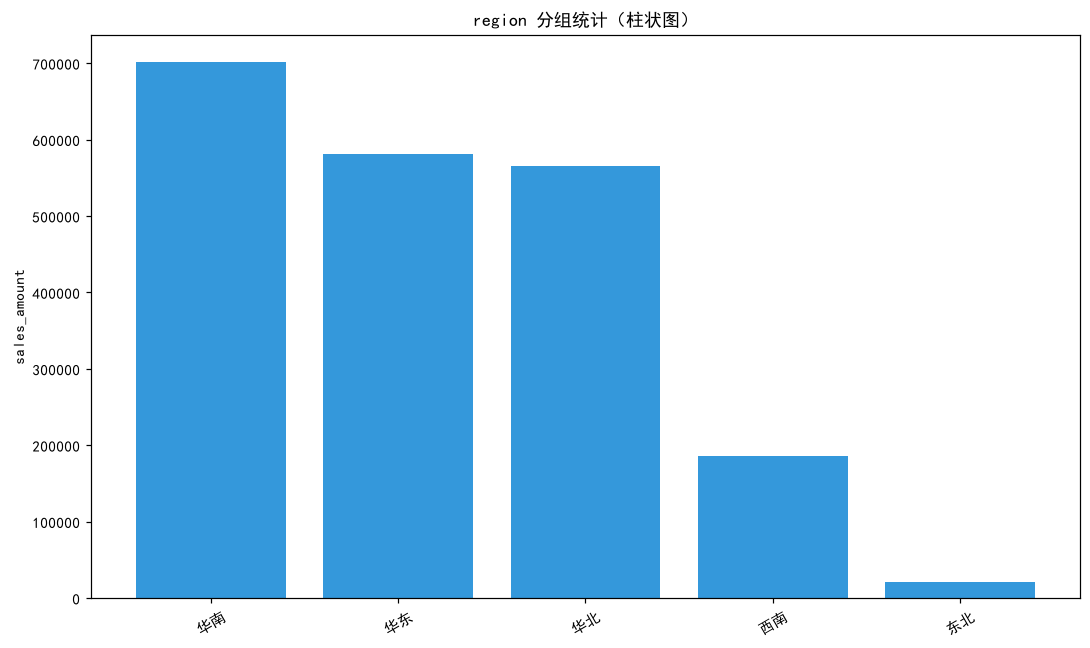

In [12]:
print("=== 示例2：复杂场景（端到端完整分析） ===")
result = agent.run(
    "请对 data/sample_sales.csv 做一次完整的销售分析："
    "先检查并清洗数据质量问题，然后对比各区域的销售表现，"
    "生成一张区域销售额柱状图，再分析客户满意度情况，"
    "最后总结关键发现并给出下半年的业务建议。"
)
print(result)

# 查看最新生成的柱状图
import glob
from IPython.display import Image, display
charts = sorted(glob.glob("outputs/bar_*.png"))
if charts:
    display(Image(filename=charts[-1]))

## 第6部分：性能评估

从两个维度评估项目质量：

1. **工具层自动化测试**：直接实例化 4 个工具，验证正常/异常输入均正确返回
2. **Agent 层定性评估**：从准确性、完整性、格式规范性等维度人工打分

In [13]:
# ---------- 1. 工具层自动化测试（不消耗 API） ----------
from hello_agents.tools import ToolStatus

def ok_status(resp, keyword):
    """判断通过条件：响应文本包含预期关键字（成功/失败用例均适用）"""
    return keyword in str(getattr(resp, "text", resp))

test_cases = [
    # (用例名, 工具实例, 参数, 预期关键字)
    ("加载-正常路径",     CSVLoaderTool(), {"file_path": DATA_PATH}, "数据规模"),
    ("加载-路径不存在",   CSVLoaderTool(), {"file_path": "data/no.csv"}, "不存在"),
    ("统计-全表",         DataStatsTool(), {"file_path": DATA_PATH}, "数值列统计"),
    ("统计-单列",         DataStatsTool(), {"file_path": DATA_PATH, "column": "region"}, "取值分布"),
    ("清洗-含缺失与重复", DataCleanTool(), {"file_path": DATA_PATH}, "重复行处理"),
    ("绘图-柱状图",       DataVizTool(),   {"file_path": DATA_PATH, "chart_type": "bar",
                                             "x_column": "region", "y_column": "sales_amount"}, "图表已生成"),
    ("绘图-不支持类型",   DataVizTool(),   {"file_path": DATA_PATH, "chart_type": "radar",
                                             "x_column": "a", "y_column": "b"}, "不支持"),
]

passed = 0
print(f"{'用例':<18}{'结果':<6}说明")
print("-" * 64)
for name, tool, params, expected in test_cases:
    try:
        resp = tool.run(params)
        ok = ok_status(resp, expected)
    except Exception as e:
        ok, resp = False, str(e)
    passed += ok
    print(f"{name:<18}{'✅' if ok else '❌':<6}{str(resp)[:46]}")

print(f"\n工具层测试：{passed}/{len(test_cases)} 通过")

# ---------- 2. Agent 层定性评估维度（人工打分表） ----------
print("""
Agent 层评估维度（满分5分，人工评估）：
| 维度           | 说明                                    | 得分 |
|----------------|-----------------------------------------|------|
| 工具选择准确性 | 是否选用了正确的工具与参数               |  _   |
| 分析完整性     | 是否覆盖了用户要求的全部分析环节          |  _   |
| 洞察价值       | 结论是否有数字支撑、建议是否可执行        |  _   |
| 输出规范性     | 是否遵循系统提示词规定的Markdown结构      |  _   |
""")

用例                结果    说明
----------------------------------------------------------------
加载-正常路径           ✅     ToolResponse(status=<ToolStatus.SUCCESS: 'succ
加载-路径不存在          ✅     ToolResponse(status=<ToolStatus.ERROR: 'error'
统计-全表             ✅     ToolResponse(status=<ToolStatus.SUCCESS: 'succ
统计-单列             ✅     ToolResponse(status=<ToolStatus.SUCCESS: 'succ
清洗-含缺失与重复         ✅     ToolResponse(status=<ToolStatus.SUCCESS: 'succ
绘图-柱状图            ✅     ToolResponse(status=<ToolStatus.SUCCESS: 'succ
绘图-不支持类型          ✅     ToolResponse(status=<ToolStatus.ERROR: 'error'

工具层测试：7/7 通过

Agent 层评估维度（满分5分，人工评估）：
| 维度           | 说明                                    | 得分 |
|----------------|-----------------------------------------|------|
| 工具选择准确性 | 是否选用了正确的工具与参数               |  _   |
| 分析完整性     | 是否覆盖了用户要求的全部分析环节          |  _   |
| 洞察价值       | 结论是否有数字支撑、建议是否可执行        |  _   |
| 输出规范性     | 是否遵循系统提示词规定的Markdown结构      |  _   |



## 第7部分：总结与展望

### 实现的功能
- ✅ 自然语言驱动的端到端数据分析：加载 → 诊断 → 清洗 → 统计 → 可视化 → 洞察
- ✅ 4 个结构化参数工具（csv_loader / data_stats / data_cleaner / data_visualizer），遵循 hello-agents 1.x 新版 `Tool`/`ToolResponse` 协议
- ✅ 智能图表选型：Agent 根据分析意图自动选择柱状/折线/饼图/直方图/散点图
- ✅ 数据质量自动诊断与修复：缺失值（中位数/众数填充）、重复行删除
- ✅ 结构化分析报告输出：数据概况 / 关键发现 / 图表 / 业务建议

### 遇到的挑战
- **挑战1：框架新旧版 API 差异** —— 教程旧模板使用 `BaseTool` + `agent.add_tool()`，而 hello-agents 1.x 已改为 `Tool`（构造时传 name/description、`run()` 返回 `ToolResponse`、`get_parameters()` 声明参数）+ `ToolRegistry` 注册后经 `tool_registry=` 注入 Agent。
  *解决方案*：研读已安装包的源码（`tools/base.py`、`tools/registry.py`、`agents/simple_agent.py`），按 1.x 新协议重写。
- **挑战2：LLM 工具参数不稳定** —— LLM 偶发漏传可选参数。
  *解决方案*：把参数设计成结构化 `ToolParameter`（必填/可选 + 类型转换），`run()` 内部对缺失参数容错。
- **挑战3：脏数据导致绘图崩溃** —— 空字符串被读成 object 列直接绘图报错。
  *解决方案*：可视化工具内先 `pd.to_numeric(errors="coerce")` 再 `dropna`，并在第6部分加入自动化回归测试。

### 未来改进方向
- 支持多轮对话式分析（追问与下钻）
- 接入 SQL 数据源与 Excel 文件，扩展数据接入能力
- 增加异常检测、相关性分析、简单预测等高级分析工具
- 输出自动生成 PDF/HTML 完整分析报告
- 引入多 Agent 协作：清洗 Agent、统计 Agent、报告 Agent 分工协作
